In [19]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [20]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
from pathlib import Path
import importlib
import numpy as np
import torch
import matplotlib.pyplot as plt

# Asegura que el ROOT esté en sys.path para poder importar src/*
ROOT = Path().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)
print("Python:", sys.version)
print("Torch:", torch.__version__)


ROOT: C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025
Python: 3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:39:58) [MSC v.1943 64 bit (AMD64)]
Torch: 2.5.1+cpu


In [21]:
import importlib

# (opcional) recarga módulos si estás editando código en caliente
import src.trainer.schrodinger_train as sch_train
import src.nn.DVPDESolver as dv_solver_mod
import src.problems.schrodinger as sch_prob

importlib.reload(sch_train)
importlib.reload(dv_solver_mod)
importlib.reload(sch_prob)

# ===== Imports correctos =====
from src.trainer.schrodinger_train import train
from src.nn.DVPDESolver import DVPDESolver

from src.problems.schrodinger import build_eq_params, sanity_check
from src.problems.schrodinger.problem import build_problem

from src.utils.logger import Logging

print("Imports OK.")



Imports OK.


In [22]:
from src.utils.nb_run_logger import NBRunLogger
from pathlib import Path

NOTEBOOK_PATH = Path(r"./prueba_barrera_dv_pasos_exito2 v05.ipynb")  # ajusta

seed = 0
run_logger = NBRunLogger("barrier", "DV", seed=seed, tag="pasos_v05")
run_logger.enable_autosave_figures_each_cell()

print("RUN_DIR:", run_logger.run_dir.resolve())



RUN_DIR: C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\barrier\DV\20260212-150909_seed0_pasos_v05


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32   # para pruebas rápidas
print("device:", device, "| dtype:", dtype)

# ====== PARAMETROS DEL PROBLEMA: BARRERA ======
eq_params = build_eq_params(
    "barrier",
    L=1.0,
    T=0.2,
    n_level=1,      # ojo: en barrier es índice 0-based en tu exact numérica
    mass=1.0,
    hbar=1.0,
    # barrera
    V0=5.0,
    barrier_width=0.2,
    x_center=0.6,
    # malla para exact numérico
    num_grid=400,
)

print("eq_params:", eq_params)


device: cpu | dtype: torch.float32
eq_params: {'example': 'barrier', 'L': 1.0, 'T': 0.2, 'mass': 1.0, 'hbar': 1.0, 'n_level': 1, 'x_min': 0.0, 'x_max': 1.0, 'omega': 1.0, 'V0': 5.0, 'barrier_width': 0.2, 'x_center': 0.6, 'num_grid': 400}


In [24]:
# Guarda parámetros globales del problema (comunes a todas las etapas)
run_logger.save_json("eq_params.json", eq_params)


WindowsPath('results/barrier/DV/20260212-150909_seed0_pasos_v05/artifacts/eq_params.json')

In [25]:
from pathlib import Path
dv_file = ROOT / "src" / "nn" / "DVPDESolver.py"
txt = dv_file.read_text(encoding="utf-8", errors="ignore")

# buscamos el patrón correcto de rotación: re2 = re*c + im*s ; im2 = im*c - re*s
ok1 = ("re2 = re * c + im * s" in txt) or ("re2 = re*c + im*s" in txt)
ok2 = ("im2 = im * c - re * s" in txt) or ("im2 = im*c - re*s" in txt)

print("DVPDESolver.py:", dv_file)
print("Global-phase sign OK?:", ok1 and ok2)

if not (ok1 and ok2):
    print("\n⚠️  Parece que el signo NO está corregido.")
    print("    Corrige _apply_global_phase para implementar exp(-i ω t).")


DVPDESolver.py: C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\src\nn\DVPDESolver.py
Global-phase sign OK?: True


In [26]:
def predict_psi(model, t, x):
    """Devuelve psi_pred (complejo) como tensor complejo shape [N,1]."""
    tx = torch.cat([t, x], dim=1)
    out = model(tx)
    re = out[:, 0:1]
    im = out[:, 1:2]
    return re + 1j * im

def exact_psi(problem, n_level, t, x):
    """Devuelve psi_exact (complejo) y también E."""
    re_e, im_e, E = problem["exact"](n_level, t, x)
    return (re_e + 1j * im_e), E

def density(psi):
    return (psi.real**2 + psi.imag**2)

def l2_rel(a, b, eps=1e-12):
    """L2 relativo estándar."""
    num = torch.sqrt(torch.mean(torch.abs(a - b)**2))
    den = torch.sqrt(torch.mean(torch.abs(b)**2)) + eps
    return num / den

def l2_rel_phase_invariant(psi_pred, psi_exact, eps=1e-12):
    """L2 relativo tras alinear fase global óptima alpha."""
    alpha = (torch.mean(torch.conj(psi_pred) * psi_exact) /
             (torch.mean(torch.conj(psi_pred) * psi_pred) + eps))
    psi_corr = alpha * psi_pred
    return l2_rel(psi_corr, psi_exact)

def plot_density_1d(problem, model, title="", n_pts=600):
    device_ = next(model.parameters()).device
    dtype_  = next(model.parameters()).dtype

    x = torch.linspace(problem["x_min"], problem["x_max"], n_pts, device=device_, dtype=dtype_).reshape(-1,1)

    for t_val, tag in [(0.0, "t=0"), (float(problem["T"]), f"t=T={problem['T']}")]:
        t = torch.full_like(x, t_val)
        with torch.no_grad():
            psi_p = predict_psi(model, t, x)
            psi_e, _ = exact_psi(problem, problem["n_level"], t, x)
            rho_p = density(psi_p).detach().cpu().numpy().flatten()
            rho_e = density(psi_e).detach().cpu().numpy().flatten()
            x_np  = x.detach().cpu().numpy().flatten()

        plt.figure(figsize=(7.2,3.4))
        plt.plot(x_np, rho_e, label="Exact")
        plt.plot(x_np, rho_p, "--", label="Pred")
        plt.title(f"{title} |psi(x,{tag})|^2")
        plt.xlabel("x")
        plt.ylabel("|psi|^2")
        plt.legend()
        plt.tight_layout()
        plt.show()

def quick_metrics(problem, model, t_val=None, n_pts=400):
    """Imprime L2 complejo, L2 fase-invariante y L2 densidad."""
    device_ = next(model.parameters()).device
    dtype_  = next(model.parameters()).dtype

    x = torch.linspace(problem["x_min"], problem["x_max"], n_pts, device=device_, dtype=dtype_).reshape(-1,1)
    if t_val is None:
        t_val = float(problem["T"])
    t = torch.full_like(x, float(t_val))

    with torch.no_grad():
        psi_p = predict_psi(model, t, x)
        psi_e, E = exact_psi(problem, problem["n_level"], t, x)
        rho_p = density(psi_p)
        rho_e = density(psi_e)

        l2_c   = l2_rel(psi_p, psi_e).item()
        l2_ph  = l2_rel_phase_invariant(psi_p, psi_e).item()
        l2_rho = l2_rel(rho_p, rho_e).item()

    print(f"[Metrics @ t={t_val}] L2_complex={l2_c:.4f} | L2_phase={l2_ph:.4f} | L2_density={l2_rho:.4f}")
    return E


In [27]:
problem = build_problem(eq_params, device=device, dtype=dtype)

args_stage1 = {
    "eq_params": eq_params,
    "device": device,
    "dtype": dtype,
    "problem": "schrodinger",

    # training (rápido)
    "epochs": 7,
    "warmup_epochs": 0,
    "lr": 1e-3,
    "batch_size": 64,
    "print_every": 1,

    # losses: SOLO IC (PDE apagado)
    "w_pde": 0.0,
    "w_pde_i": 1.0,     # irrelevante si w_pde=0
    "w_ic": 800.0,
    "w_ic_i": 5.0,
    "w_norm": 0.0,

    # BC dura
    "hard_bc": True,
    "w_bc": 0.0,
    "hard_bc_power": 1.0,
    "hard_bc_scale": 4.0,

    # IC sampling / val
    "ic_grid": True,
    "N_norm": 400,
    "N_val": 400,

    # DV circuit
    "num_qubits": 4,
    "num_quantum_layers": 2,
    "shots": None,
    "noise": False,
    "encoding": "angle",
    "q_ansatz": "sim_circ_19",

    # hybrid net
    "classic_network": [2, 64, 64, 2],

    # performance / métricas
    "pde_chunk_size": 64,
    "l2_every": 10,

    # fase global (se mantiene igual en ambas etapas)
    "global_phase": True,
    "global_phase_spatial_only": True,
    "global_phase_omega_init": 5.0,
    "use_lbfgs": False,

    # estabilidad de ángulos (si tu DVPDESolver lo soporta)
    "angle_squash": True,
}

model = DVPDESolver(args_stage1, logger=Logging(ROOT / "results"), device=device).to(device)
print("Model dtype:", next(model.parameters()).dtype)


Model dtype: torch.float32


In [28]:
pc = run_logger.log_param_count(model)
print("Trainable params:", pc)

Trainable params: {'total': 919, 'quantum': 16, 'classical': 903}


In [29]:
import logging, sys
from pathlib import Path
from contextlib import contextmanager

def force_live_logging(log_file: Path, level=logging.INFO):
    log_file.parent.mkdir(parents=True, exist_ok=True)
    logging.disable(logging.NOTSET)
    logging.basicConfig(
        level=level,
        format="%(levelname)s:%(name)s:%(message)s",
        handlers=[logging.StreamHandler(sys.stdout),
                  logging.FileHandler(log_file, encoding="utf-8")],
        force=True,
    )
    for name in ["src.utils.logger", "src.trainer.schrodinger_train"]:
        lg = logging.getLogger(name)
        lg.setLevel(level)
        lg.propagate = True
        lg.disabled = False
    sys.stdout.flush()

@contextmanager
def stage(stage_id: str, desc: str, args_snapshot: dict, train_kwargs: dict):
    """
    Crea subcarpeta por etapa y deja TODO lo de esa etapa ahí:
    - artifacts/<stage_id>/: stage_meta.json, python.log, curvas parseadas, etc.
    - figures/<stage_id>/: todas las figuras de esa etapa
    """
    old_art, old_fig = run_logger.art_dir, run_logger.fig_dir

    stage_art = old_art / stage_id
    stage_fig = old_fig / stage_id
    stage_art.mkdir(parents=True, exist_ok=True)
    stage_fig.mkdir(parents=True, exist_ok=True)

    # redirige escrituras del run_logger a carpeta de etapa
    run_logger.art_dir = stage_art
    run_logger.fig_dir = stage_fig

    # logging live + archivo (por etapa)
    force_live_logging(stage_art / "python.log", level=logging.INFO)

    # evita duplicados: que SOLO el root escriba
    lg = logging.getLogger("src.utils.logger")
    lg.handlers.clear()
    lg.propagate = True
    lg.disabled = False
    lg.setLevel(logging.INFO)

    # guarda snapshot de parámetros de la etapa
    run_logger.save_json("stage_meta.json", {
        "stage_id": stage_id,
        "description": desc,
        "train_kwargs": train_kwargs,
        "args_snapshot": args_snapshot,
    })

    try:
        yield
    finally:
        # fuerza guardado de figuras pendientes
        run_logger.flush_figures()

        # parsea el log de ESA etapa (queda todo dentro de stage_art)
        try:
            run_logger.parse_schrodinger_train_log(log_name="python.log")
        except TypeError:
            # por si tu versión no acepta log_name
            run_logger.parse_schrodinger_train_log()

        # regresa a carpetas globales
        run_logger.art_dir, run_logger.fig_dir = old_art, old_fig


In [30]:
import logging, sys
from pathlib import Path

def force_live_logging(log_file: Path, level=logging.INFO):
    log_file.parent.mkdir(parents=True, exist_ok=True)
    logging.disable(logging.NOTSET)

    logging.basicConfig(
        level=level,
        format="%(levelname)s:%(name)s:%(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, encoding="utf-8"),
        ],
        force=True,
    )

    for name in ["src.utils.logger", "src.trainer.schrodinger_train"]:
        lg = logging.getLogger(name)
        lg.setLevel(level)
        lg.propagate = True
        lg.disabled = False

    sys.stdout.flush()

force_live_logging(run_logger.art_dir / "python.log")


In [31]:
import logging
lg = logging.getLogger("src.utils.logger")
lg.handlers.clear()
lg.propagate = True
lg.disabled = False
lg.setLevel(logging.INFO)


INFO:src.utils.logger:The circuit used in the study:


INFO:src.utils.logger:It: 1, Loss: 1.403e+03, Loss_res: 2.475e+00,  Loss_bcs: 0.000e+00, Loss_ut_ics: 1.754e+00, Loss_norm: 6.955e-01, Loss_gauge: 0.000e+00, w_pde: 0.00e+00, L^2_error: 1.088e+00, lr: 1.000e-03, Time: 5.76e+00
INFO:src.utils.logger:Model state saved to C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\2026-02-12_15-09-09-698947\model.pth
INFO:src.utils.logger:Model weights saved to C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\2026-02-12_15-09-09-698947\model_weights.pth
INFO:src.utils.logger:It: 2, Loss: 1.260e+03, Loss_res: 1.949e+00,  Loss_bcs: 0.000e+00, Loss_ut_ics: 1.575e+00, Loss_norm: 7.556e-01, Loss_gauge: 0.000e+00, w_pde: 0.00e+00, L^2_error: 1.088e+00, lr: 1.000e-03, Time: 9.64e+00
INFO:src.utils.logger:Model state saved to C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\2026-02-12_15-09-09-698947\model.pth
INFO:src.utils.logger:Model weights saved to C:\Users\mateo garcia\Documents\A master\Tesis\QPI

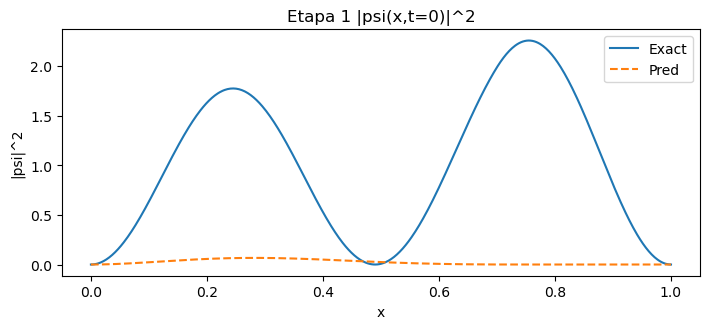

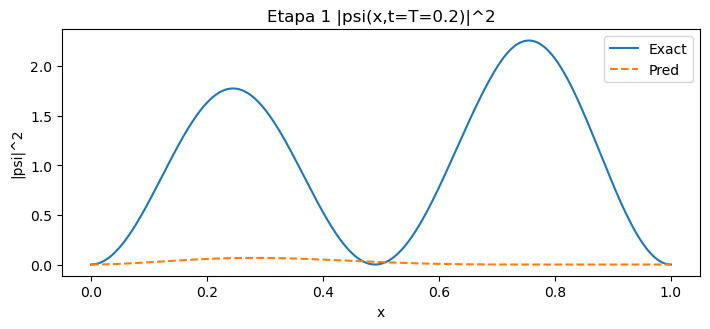

[Metrics @ t=0.0] L2_complex=0.9735 | L2_phase=0.8285 | L2_density=0.9843


In [32]:
with stage(
    stage_id="stage1_ic_only",
    desc="Etapa 1: entrenamiento solo con condición inicial (w_pde=0)",
    args_snapshot=args_stage1,                      # tu dict stage1
    train_kwargs={"N_f": 512, "N_b": 0, "N_0": 1000}
):
    train(model, N_f=512, N_b=0, N_0=1000)

    print("\nEtapa 1 (IC-only) terminada.")
    plot_density_1d(problem, model, title="Etapa 1")
    E = quick_metrics(problem, model, t_val=0.0)
    run_logger.save_json("metrics.json", {"t_val": 0.0, "metrics": E})

In [33]:
# Calcula E/hbar usando exact (en cualquier x0 sirve)
device_ = next(model.parameters()).device
dtype_  = next(model.parameters()).dtype

x0 = torch.tensor([[0.37]], device=device_, dtype=dtype_)
t0 = torch.zeros_like(x0)

with torch.no_grad():
    psi_e0, E = exact_psi(problem, problem["n_level"], t0, x0)
omega_star = float((E / problem["hbar"]).detach().cpu())

print("E =", float(E.detach().cpu()))
print("omega_star = E/hbar =", omega_star)

# set + freeze
if hasattr(model, "global_phase_omega"):
    model.global_phase_omega.data.fill_(omega_star)
    model.global_phase_omega.requires_grad_(False)
    print("✅ omega fijada y congelada.")
else:
    print("⚠️ Tu modelo no tiene global_phase_omega. Revisa DVPDESolver.")


E = 20.553302764892578
omega_star = E/hbar = 20.553302764892578
✅ omega fijada y congelada.


INFO:src.utils.logger:It: 1, Loss: 8.288e+02, Loss_res: 4.090e+00,  Loss_bcs: 0.000e+00, Loss_ut_ics: 1.021e+00, Loss_norm: 9.550e-01, Loss_gauge: 0.000e+00, w_pde: 5.00e-01, L^2_error: 9.683e-01, lr: 1.000e-03, Time: 3.56e+00
INFO:src.utils.logger:Model state saved to C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\2026-02-12_15-09-09-698947\model.pth
INFO:src.utils.logger:Model weights saved to C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\2026-02-12_15-09-09-698947\model_weights.pth
INFO:src.utils.logger:It: 2, Loss: 7.997e+02, Loss_res: 2.322e+00,  Loss_bcs: 0.000e+00, Loss_ut_ics: 9.846e-01, Loss_norm: 9.686e-01, Loss_gauge: 0.000e+00, w_pde: 1.00e+00, L^2_error: 9.683e-01, lr: 1.000e-03, Time: 6.98e+00
INFO:src.utils.logger:Model state saved to C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\2026-02-12_15-09-09-698947\model.pth
INFO:src.utils.logger:Model weights saved to C:\Users\mateo garcia\Documents\A master\Tesis\QPI

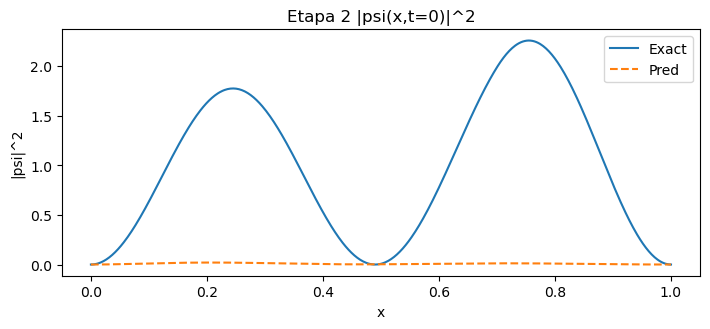

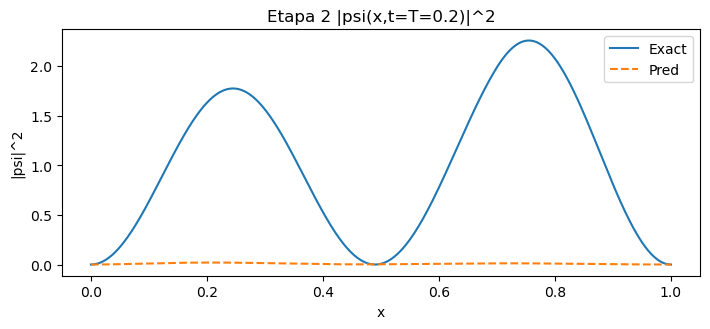

[Metrics @ t=0.2] L2_complex=0.9439 | L2_phase=0.4279 | L2_density=0.9924


In [34]:
# Actualiza args dentro del modelo (train() lee model.args)
model.args["epochs"] = 7
model.args["warmup_epochs"] = 2

model.args["w_pde"] = 1.0
model.args["w_pde_i"] = 1.0       # importante: NO 10
model.args["w_norm"] = 10.0

# dejamos IC igual
model.args["w_ic"] = 800.0
model.args["w_ic_i"] = 5.0

model.args["use_lbfgs"] = False
model.args["angle_squash"] = True

args_stage2 = dict(model.args)   # snapshot justo DESPUÉS de tus cambios de etapa 2

with stage(
    stage_id="stage2_physics",
    desc="Etapa 2: activa PDE + normalización (w_pde=1, w_norm=10, warmup=100)",
    args_snapshot=args_stage2,
    train_kwargs={"N_f": 512, "N_b": 0, "N_0": 1000}
):
    train(model, N_f=512, N_b=0, N_0=1000)

    print("\nEtapa 2 (Physics-informed) terminada.")
    plot_density_1d(problem, model, title="Etapa 2")
    E = quick_metrics(problem, model, t_val=float(problem["T"]))
    run_logger.save_json("metrics.json", {"t_val": float(problem["T"]), "metrics": E})


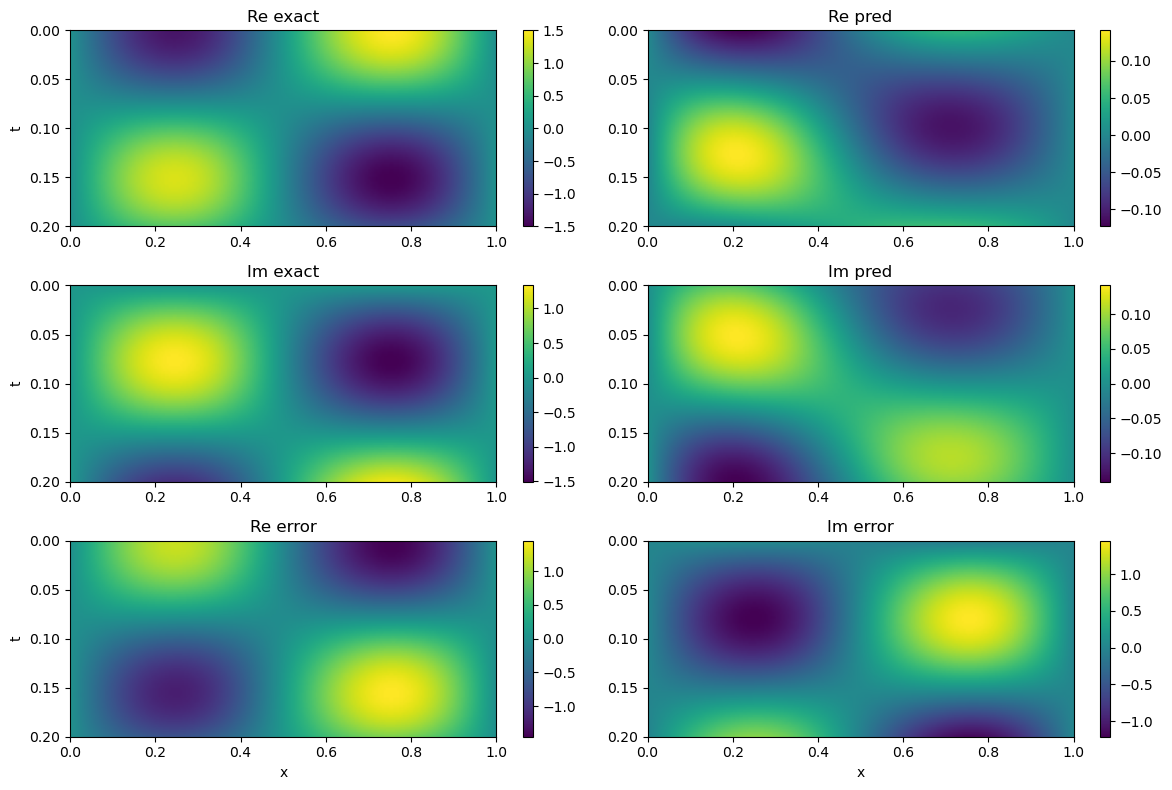

In [35]:
import numpy as np

Nt, Nx = 80, 220
t_grid = torch.linspace(0.0, float(problem["T"]), Nt, device=device_, dtype=dtype_).reshape(-1,1)
x_grid = torch.linspace(problem["x_min"], problem["x_max"], Nx, device=device_, dtype=dtype_).reshape(-1,1)

# mallado tipo (Nt*Nx, 1)
TT = t_grid.repeat(1, Nx).reshape(-1,1)
XX = x_grid.repeat(Nt, 1)

with torch.no_grad():
    re_ex, im_ex, _ = problem["exact"](problem["n_level"], TT, XX)
    y_pr = model(torch.cat([TT, XX], dim=1))
    re_pr, im_pr = y_pr[:,0:1], y_pr[:,1:2]

re_ex = re_ex.reshape(Nt, Nx).detach().cpu().numpy()
im_ex = im_ex.reshape(Nt, Nx).detach().cpu().numpy()
re_pr = re_pr.reshape(Nt, Nx).detach().cpu().numpy()
im_pr = im_pr.reshape(Nt, Nx).detach().cpu().numpy()

re_er = re_pr - re_ex
im_er = im_pr - im_ex

extent = [float(problem["x_min"]), float(problem["x_max"]), float(problem["T"]), 0.0]

plt.figure(figsize=(12,8))

plt.subplot(3,2,1); plt.imshow(re_ex, aspect="auto", extent=extent); plt.title("Re exact"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,2); plt.imshow(re_pr, aspect="auto", extent=extent); plt.title("Re pred");  plt.colorbar()

plt.subplot(3,2,3); plt.imshow(im_ex, aspect="auto", extent=extent); plt.title("Im exact"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,4); plt.imshow(im_pr, aspect="auto", extent=extent); plt.title("Im pred");  plt.colorbar()

plt.subplot(3,2,5); plt.imshow(re_er, aspect="auto", extent=extent); plt.title("Re error"); plt.xlabel("x"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,6); plt.imshow(im_er, aspect="auto", extent=extent); plt.title("Im error"); plt.xlabel("x"); plt.colorbar()

plt.tight_layout()
plt.show()


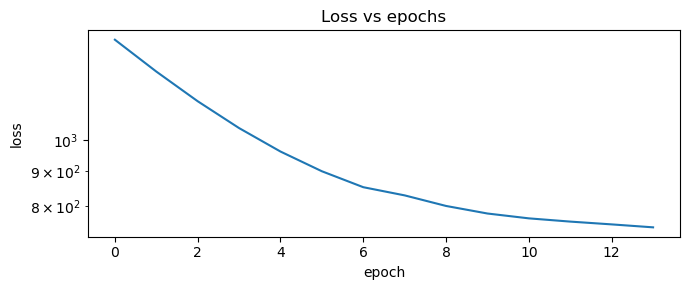

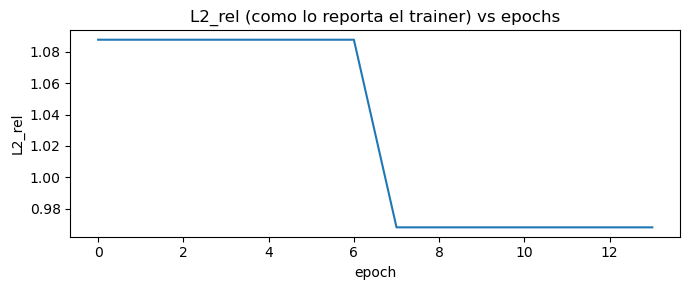

In [36]:
loss_hist = np.array(getattr(model, "loss_history", []), dtype=float)
l2_hist   = np.array(getattr(model, "l2_rel_history", []), dtype=float)

plt.figure(figsize=(7,3))
if len(loss_hist) > 0:
    plt.plot(loss_hist)
plt.yscale("log")
plt.title("Loss vs epochs")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,3))
if len(l2_hist) > 0:
    plt.plot(l2_hist)
plt.title("L2_rel (como lo reporta el trainer) vs epochs")
plt.xlabel("epoch")
plt.ylabel("L2_rel")
plt.tight_layout()
plt.show()


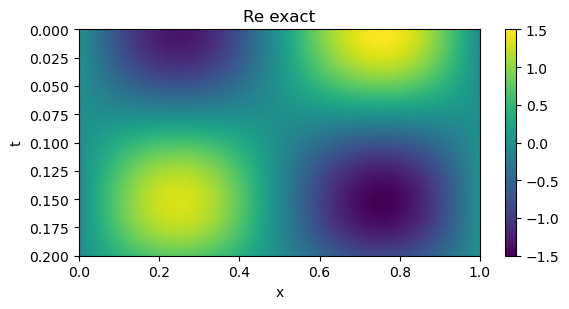

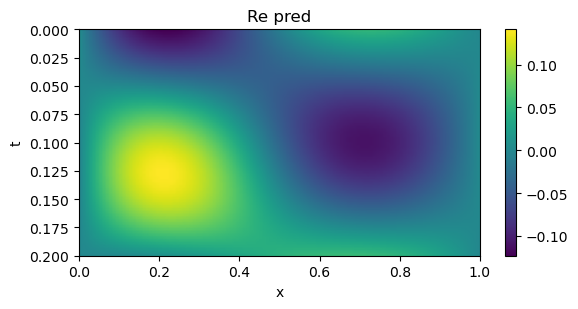

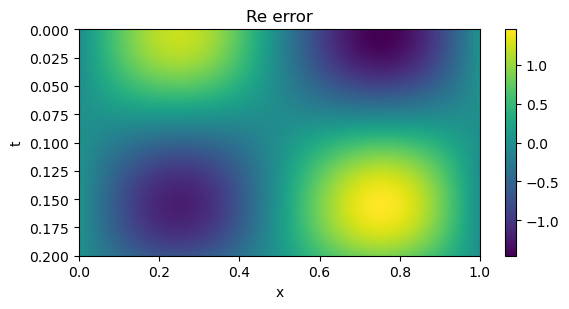

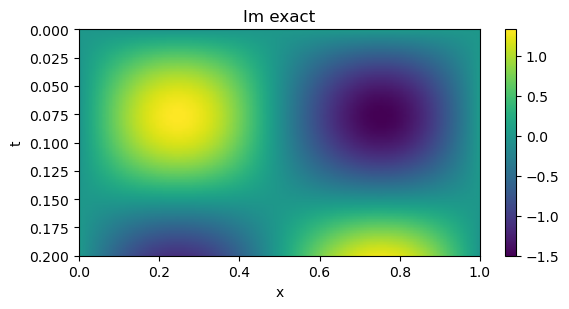

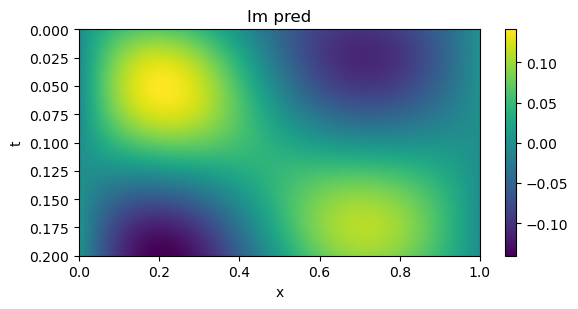

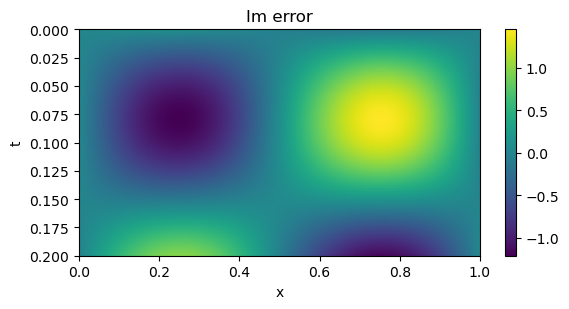

In [37]:
def plot_heatmaps(problem, model, nx=120, nt=80):
    device_ = next(model.parameters()).device
    dtype_  = next(model.parameters()).dtype

    x = torch.linspace(problem["x_min"], problem["x_max"], nx, device=device_, dtype=dtype_).reshape(-1,1)
    t = torch.linspace(0.0, float(problem["T"]), nt, device=device_, dtype=dtype_).reshape(-1,1)

    TT, XX = torch.meshgrid(t.squeeze(1), x.squeeze(1), indexing="ij")
    tx = torch.stack([TT.reshape(-1), XX.reshape(-1)], dim=1)

    with torch.no_grad():
        out = model(tx)
        re_p = out[:,0].reshape(nt, nx).detach().cpu().numpy()
        im_p = out[:,1].reshape(nt, nx).detach().cpu().numpy()

        re_e, im_e, _ = problem["exact"](problem["n_level"], tx[:,0:1], tx[:,1:2])
        re_e = re_e.reshape(nt, nx).detach().cpu().numpy()
        im_e = im_e.reshape(nt, nx).detach().cpu().numpy()

    def show(A, title):
        plt.figure(figsize=(6,3.2))
        plt.imshow(A, aspect="auto", origin="upper",
                   extent=[float(problem["x_min"]), float(problem["x_max"]), float(problem["T"]), 0.0])
        plt.colorbar()
        plt.title(title)
        plt.xlabel("x")
        plt.ylabel("t")
        plt.tight_layout()
        plt.show()

    show(re_e, "Re exact")
    show(re_p, "Re pred")
    show(re_p - re_e, "Re error")

    show(im_e, "Im exact")
    show(im_p, "Im pred")
    show(im_p - im_e, "Im error")

plot_heatmaps(problem, model)


In [ ]:
run_logger.flush_figures()
print("Figuras guardadas:", len(list(run_logger.fig_dir.glob("*.png"))))

Figuras guardadas: 9
